In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import models._config as c

from models._config import *
from sklearn.utils import shuffle

import warnings 
warnings.filterwarnings('ignore')

# 기본 설정
fs = 100e6
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_class_dB'

data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snrs_batch = numpy_load(save_dir, 'snr_batch.npy')
idxs_batch = numpy_load(save_dir, 'idx_batch.npy')

data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}

In [ ]:
from metrics import *

snr_values = sorted(set(snrs_batch.flatten()))  
score_snr_dict = {snr: {waveform: {'score': [], 'Nscore': [], 'Wscore': [], 'Rscore': []} for waveform in c.waveforms} for snr in snr_values}


for batch in range(len(data_dict)):
    batch_key = f'arr_{batch}'
    datab = data_dict[batch_key]
    labelb = labels_dict[batch_key]
    relevanceb = relevance_dict[batch_key]

    datab, labelb, lengthb, relevanceb, snrb, idxb = shuffle(datab, labelb, lengths_batch[batch], relevanceb, snrs_batch[batch], idxs_batch[batch])
    for j, sample in enumerate(zip(datab, labelb, lengthb, relevanceb, snrb, idxb)):  
        fig, axes = plt.subplots(7, 3, figsize=(18, 20))  # 플롯 크기 설정
        data, label, length, relevance, snr, idx = sample
        fig.suptitle(f'{c.waveforms[label]} at {snr}dB - {idx}', fontsize=24, y=1.03)
        
        wav_path = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
        wav = np.load(wav_path)
        
        x = data[:length].cpu().numpy().T
        R_x = relevance[:length].cpu().numpy().T
        R_x = highpass_filter(R_x, 1e6, fs)
        

        
        row = 1
        wf, wa, wfft = fft_transform(wav.real, wav.imag)
        f_w, t_w, Zxx_w = stft_transform(wav.real, wav.imag)
        axes[0, 0].plot(wav, label='Original Signal')
        axes[0, 1].plot(wfft, label='FFT of Original Signal')
        axes[0, 2].pcolormesh(t_w, f_w[:len(f_w)//2], Zxx_w[:len(f_w)//2], shading='gouraud', cmap='jet')
        axes[0, 0].set_title('Original Signal (w)')
        
        # Row 1: 원본 데이터 및 FFT/STFT 결과
        r = row
        x = comp(x[0], x[1])
        xf, xa, xfft = fft_transform(x.real, x.imag)
        f_x, t_x, Zxx_x = stft_transform(x.real, x.imag)
        axes[r, 0].plot(x, label='x')
        axes[r, 1].plot(xfft, label='FFT of x')
        axes[r, 2].pcolormesh(t_x, f_x[:len(f_x)//2], Zxx_x[:len(f_x)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Original Signal (x)')
        
        # Row 2: iFFT를 통해 복원된 데이터 결과
        r = row + 1
        i_x = relevance_k(xfft)
        i_x = ifft_transform(i_x)
        ixf, ixa, ixfft = fft_transform(i_x.real, i_x.imag)
        f_ix, t_ix, Zxx_ix = stft_transform(i_x.real, i_x.imag)
        axes[r, 0].plot(i_x, label='iFFT of x')
        axes[r, 1].plot(ixfft, label='FFT of i_x')
        axes[r, 2].pcolormesh(t_ix, f_ix[:len(f_ix)//2], Zxx_ix[:len(f_ix)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Reconstructed Signal (i_x)')
        
        # Row 3: R>0인 원본 데이터 및 FFT/STFT 결과
        r = row + 2
        R_x = comp(R_x[0], R_x[1])
        xp = np.where(R_x > 0, x, 0)
        xpf, xpa, xpfft = fft_transform(xp.real, xp.imag)
        f_xp, t_xp, Zxx_xp = stft_transform(xp.real, xp.imag)
        axes[r, 0].plot(xp, label='x(R_x > 0)')
        axes[r, 1].plot(xfft, label='FFT of x(R_x > 0)')
        axes[r, 2].pcolormesh(t_xp, f_xp[:len(f_xp)//2], Zxx_xp[:len(f_xp)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Signal x(R_x > 0)')
        
        # Row 4 : R>0인 iFFT를 통해 복원된 데이터 결과
        r = row + 3
        xk = relevance_k(xfft)
        i_xp = ifft_transform(xk)
        ixpf, ixpa, ixpfft = fft_transform(i_xp.real, i_xp.imag)
        f_ixp, t_ixp, Zxx_ixp = stft_transform(i_xp.real, i_xp.imag)
        axes[r, 0].plot(i_xp, label='iFFT of x(R_x > 0)')
        axes[r, 1].plot(ixpfft, label='FFT of i_x(R_x > 0)')
        axes[r, 2].pcolormesh(t_ixp, f_ixp[:len(f_ixp)//2],  Zxx_ixp[:len(f_ixp)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Reconstructed Signal (i_x(R_x > 0)')
        
        # Row 5 : Relevance 및 FFT/STFT 결과
        r = row + 4
        rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
        f_R_x, t_R_x, Zxx_R_x = stft_transform(R_x.real, R_x.imag)
        axes[r, 0].plot(R_x, label='R_x')
        axes[r, 1].plot(rfft, label='FFT of R_x')
        axes[r, 2].pcolormesh(t_R_x, f_R_x[:len(f_R_x)//2],  Zxx_R_x[:len(f_R_x)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Relevance (R_x)')
        
        # Row 6 : iFFT를 통해 복원된 Relevance 결과
        r = row + 5
        R_k = relevance_k(rfft)
        iR_k = ifft_transform(R_k)
        rf, ra, rfft = fft_transform(iR_k.real, iR_k.imag)
        f_R_k, t_R_k, Zxx_R_k = stft_transform(iR_k.real, iR_k.imag)
        axes[r, 0].plot(R_k, label='R_k')
        axes[r, 1].plot(rfft, label='FFT of R_k')
        axes[r, 2].pcolormesh(t_R_k, f_R_k[:len(f_R_k)//2],  Zxx_R_k[:len(f_R_k)//2], shading='gouraud', cmap='jet')
        axes[r, 0].set_title('Reconstructed Relevance (R_k)')
        
        # Row 7

        
        # 공통 설정: 각 축에 라벨 추가
        for row_axes in axes:
            for ax in row_axes:
                ax.axis('off')
                ax.grid(alpha=0.3)
        break
    break
        
plt.tight_layout()
plt.show()
        


In [2]:
def score_metrics(datas, rel, fs):
    cpo_score = cpo_metric(rel, datas, fs)
    rnr_score = relevance_metrics(rel, datas, datas, fs, metric='RNR')
    return f"CPO: {cpo_score}, RNR: {rnr_score:.3f}"


def plot_data(axs, row_idx, data, title=""):
    f, a, fft = fft_transform(data.real, data.imag, fs)
    ff, t, Zxx = stft_transform(data.real, data.imag, fs)
    axs[row_idx, 0].plot(data.real)
    axs[row_idx, 1].plot(fft)
    axs[row_idx, 2].pcolormesh(t, ff[:len(ff)//2], Zxx[:len(ff)//2], shading='gouraud', cmap='jet')
    axs[row_idx, 0].set_title(title)
    
test_dir = 'dataset/lpi_testset/'
ockpt = 'ckpts/pwnNoisy/BiLSTM_best_0.0638087096589583.pth'
ckpt = 'ckpts/pwnNoisy/BiLSTM_R>0_best_0.0208.pth'
model, lrp = load_models(ckpt, device)

import models._config as c
from sklearn.utils import shuffle


cnt = 0
for batch in range(len(data_dict)):
    key = f'arr_{batch}'
    data_batch, label_batch, relevance_batch = data_dict[key], labels_dict[key], relevance_dict[key]
    length_batch, snr_batch, idx_batch = lengths_batch[batch], snrs_batch[batch], idxs_batch[batch]
    sample = shuffle(list(zip(data_batch, label_batch, relevance_batch, length_batch, snr_batch, idx_batch)))
    for data, label, relevance, length, snr, idx in sample:
        if snr == 0 :
            x = comp(data[:length, 0], data[:length, 1])
            r = comp(relevance[:length, 0], relevance[:length, 1])
            r = highpass_filter(r, 1e6, fs)
            wav_path = os.path.join(test_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
            o = np.load(wav_path)
            # ig, saliency, deeplift = baselines(model, data, labels)   
            
            fig, axs = plt.subplots(6, 3, figsize=(20, 25))
            fig.suptitle(f'{waveforms[label[0]]} ({snr[0]}dB)', fontsize=20)

            plot_data(axs, 0, o, title=f"Original Data")
            plot_data(axs, 1, x, title=f"Original+AWGN Data")
            plot_data(axs, 2, r, title=f"Relevance (LRP)")

            xpI = np.where(r.real > 0, x.real, 0)
            xpQ = np.where(r.imag > 0, x.imag, 0)
            xp = comp(xpI, xpQ)
            xp = highpass_filter(xp, 1e6, fs)
            plot_data(axs, 3, xp, title=f"Positive Relevance Data")

            rk = relevance_k(r)
            plot_data(axs, 4, rk, title=f"Relevance Kernel")

            # print(score_metrics(x, r, fs))
            # print(score_metrics(x, rk, fs))
            # print(score_metrics(xp, r, fs))
            # print(score_metrics(xp, rk, fs))

            fig.tight_layout()
            for ax in axs.flatten():
                ax.axis('off') # param : off, on, equal, scaled, tight, image, auto
                
            cnt += 1
            break
        
    if cnt == 1:
        break
    


FileNotFoundError: [Errno 2] No such file or directory: 'ckpts/pwnNoisy/BiLSTM_R>0_best_0.0208.pth'

In [5]:

import os
import torch
import numpy as np
import models._config as c

from models._config import *
from ex_models.LRP import LRP
from models.LSTM import BiLSTM
from scipy.signal import butter, filtfilt
from warnings import filterwarnings
filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.utils import shuffle


def load_models(path='./ckpts/result_loss.pt', device='cuda:0'):
    model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(c.waveforms)).cuda()
    state_dict = {}
    for k, v in torch.load(path).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    
    lrp = LRP(model, device=device, epsilon=1e-6)
    return model ,lrp

from scipy.signal import butter, filtfilt

def highpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, data)


def gt_mask(Zxx, threshold=0.6):
    return np.where(np.abs(Zxx) > threshold * np.abs(Zxx).max(), 1, 0)

def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)

train_dir = '/data/kiwan/LPI_KIWAN/'

test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_train_class_dB'
data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snr_batch = numpy_load(save_dir, 'snr_batch.npy')
idx_batch = numpy_load(save_dir, 'idx_batch.npy')


data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}



def fo_metric(R_x, wav, fs, alpha=0.8): # Feature overlap
    # 중요 특징이 원본 신호에 얼마나 많이 포함되어 있는지를 나타내는 지표
    _, _, Z_wav = stft_transform(wav.real, wav.imag, fs=fs)
    _, _, Z_Rx = stft_transform(R_x.real, R_x.imag, fs=fs)

    tau = alpha * np.max(np.abs(Z_wav))
    P_feature = np.abs(Z_wav) > tau

    relevance_in_feature = np.sum(np.abs(Z_Rx) * P_feature)
    total_relevance = np.sum(np.abs(Z_Rx))

    cpo = relevance_in_feature / total_relevance if total_relevance > 0 else 0
    
    return cpo


def relevance_metrics(R_x, wav, x, fs, metric='PER'):
    _, _, oZxx = stft_transform(wav.real, wav.imag, fs)
    _, _, xZxx = stft_transform(x.real, x.imag, fs)
    
    R_x_positive = np.where(R_x > 0, R_x, 0)
    _, _, rZxx_p = stft_transform(R_x_positive.real, R_x_positive.imag, fs)

    if metric == 'RPO': # Relevance_Positive_Energy_Overlap 
        ov_pos = np.sum(np.abs(rZxx_p) * np.abs(xZxx))
        total_pos = np.sqrt(np.sum(np.abs(rZxx_p)**2))
        
        score = ov_pos / total_pos if total_pos > 0 else 0

    elif metric == 'RNR': # Relevance_Noise_Robustness
        ov_noisy = np.sum(np.abs(rZxx_p) * np.abs(xZxx))
        ov_original = np.sqrt(np.sum(np.abs(rZxx_p)**2 * np.abs(oZxx)**2))
        
        score = 1- ov_noisy / ov_original if ov_original > 0 else 0

    else:
        raise ValueError("Unknown metric type specified.")
    
    return score



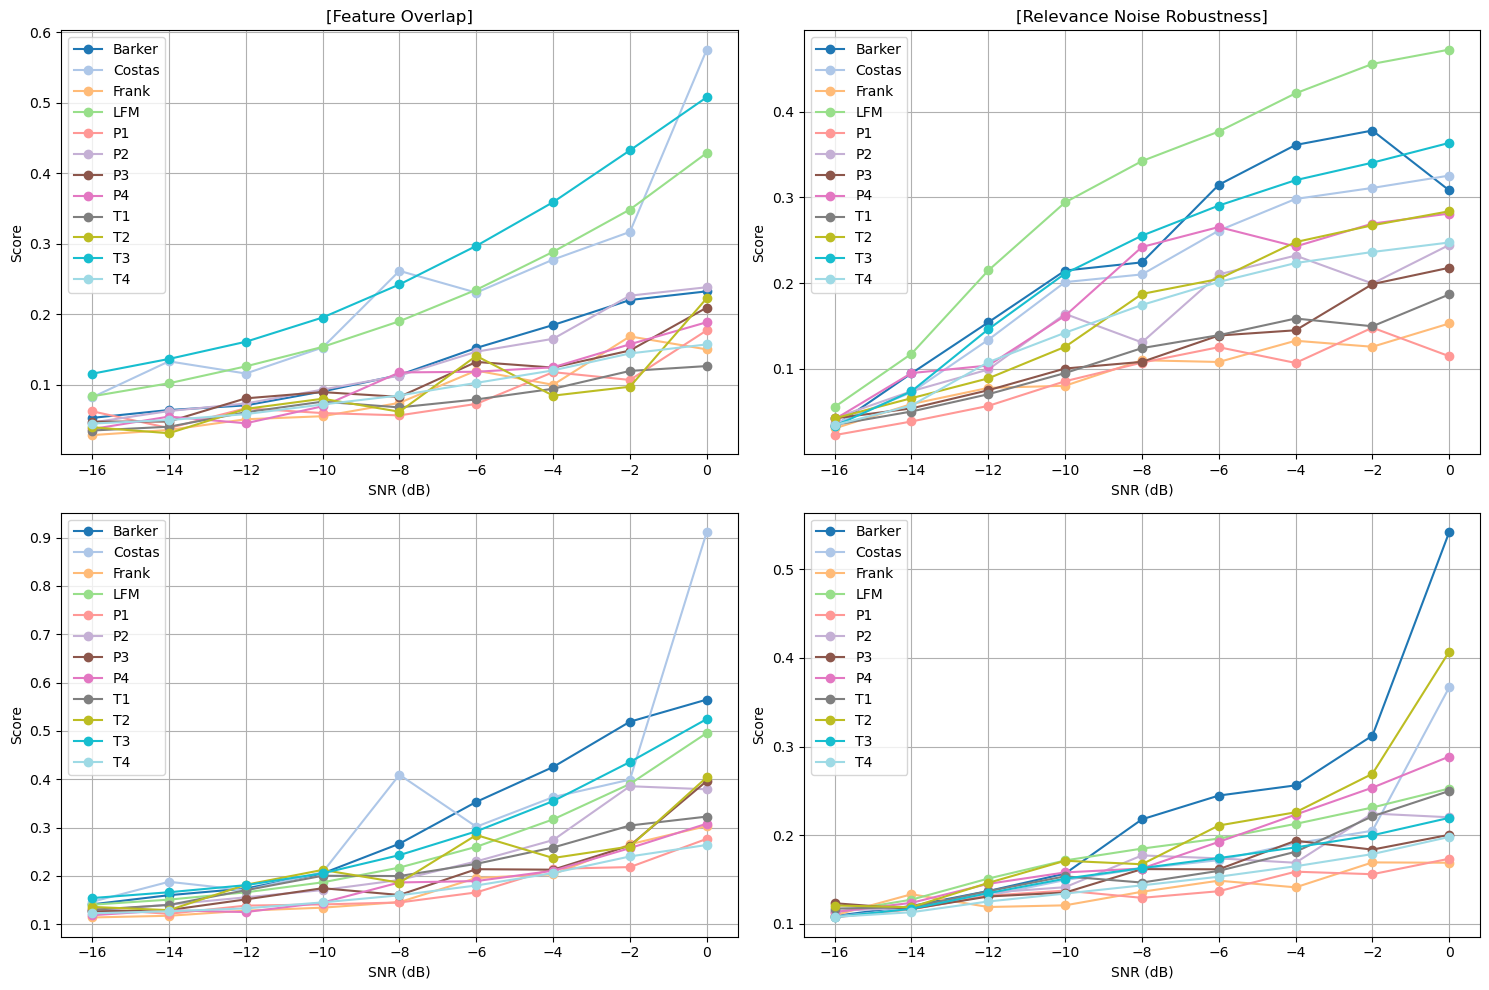

In [ ]:
snr_values = sorted(set(snr_batch.flatten()))  
score_snr_dict = {snr: {waveform: {'score1': [], 'score2': [], 'score1k': [], 'score2k': []} for waveform in c.waveforms} for snr in snr_values}

def sra_metric(Z_gt, Z_input, Z_lrp, alpha=0.8, delta=0.8):
            # Create masks
            M_gt = (np.abs(Z_gt) > alpha * np.max(np.abs(Z_gt))).astype(float)  # Feature mask
            M_noise = 1 - M_gt  # Noise mask

            # Feature Concentration (FC)
            fc_num = np.sum(np.abs(M_gt) * np.abs(Z_lrp))
            fc_den = np.sum(np.abs(M_gt) * np.abs(Z_input))
            fc = fc_num / fc_den if fc_den > 0 else 0

            # Noise Reduction (NR)
            nr_num = np.sum(np.abs(M_noise) * np.abs(Z_lrp))
            nr_den = np.sum(np.abs(M_noise) * np.abs(Z_input))
            nr = 1 - (nr_num / nr_den if nr_den > 0 else 0)

            # SRA Score
            sra = delta * fc + (1 - delta) * nr
            return sra * 100  
        
def fans_metric(gt_mask, x_mask, r_mask, delta=0.8):
    fa_num = np.sum(np.abs(gt_mask) * np.abs(r_mask))
    fa_den = np.sum(np.abs(gt_mask) * np.abs(x_mask))
    fa = fa_num / fa_den if fa_den > 0 else 0

    # Noise Suppression (NS)
    noise_mask = 1 - gt_mask  # Complement of ground truth mask
    ns_num = np.sum(np.abs(noise_mask) * np.abs(r_mask))
    ns_den = np.sum(np.abs(noise_mask) * np.abs(x_mask))
    ns = 1 - (ns_num / ns_den if ns_den > 0 else 0)

    # FANS Score
    fans_score = delta * fa + (1 - delta) * ns
    return fans_score   

def critical_overlaps(wav, R_x, fs=100e6, alpha=0.8):
    f_w, t_w, Z_w = stft_transform(wav.real, wav.imag, fs=fs)
    f_R, t_R, Z_R = stft_transform(R_x.real, R_x.imag, fs=fs)

    # 특징점 임계값 계산
    tau = alpha * np.max(np.abs(Z_w))
    
    # 특징점 영역 (Critical Point Set)
    P_feature = np.abs(Z_w) > tau

    # Relevance 신호의 특징점 영역 합산
    relevance_in_feature = np.sum(np.abs(Z_R) * P_feature)
    
    # Relevance 전체 크기 합산
    total_relevance = np.sum(np.abs(Z_R))

    # CPO 계산
    cpo_score = relevance_in_feature / total_relevance if total_relevance > 0 else 0
    return cpo_score

def relevance_noise(x, R_x, fs):
    f_x, t_x, Z_x = stft_transform(x.real, x.imag, fs=fs)
    f_R, t_R, Z_R = stft_transform(R_x.real, R_x.imag, fs=fs)

    # 유클리디안 거리 계산
    diff = np.linalg.norm(Z_R - Z_x, ord=2)
    norm = np.linalg.norm(Z_x, ord=2)

    rnr_score = 1 - (diff / norm if norm > 0 else 0)
    return rnr_score

def z_mask(Zxx, threshold=0.6):
    return np.where(np.abs(Zxx) > threshold * np.abs(Zxx).max(), 1, 0)

for batch in range(len(data_dict)):
    batch_key = f'arr_{batch}'
    data = data_dict[batch_key]
    label = labels_dict[batch_key]
    relevance = relevance_dict[batch_key]

    data, label, length, relevance, snr, idx = shuffle(data, label, lengths_batch[batch], relevance, snr_batch[batch], idx_batch[batch])
    for j, sample in enumerate(zip(data, label, length, relevance, snr, idx)):  
        data, label, length, relevance, snr, idx = sample
        
        wav_path = os.path.join(train_dir, c.waveforms[label], f'{c.waveforms[label]}_snr{snr}_Signal_{idx}.npy')
        x = data[:length].cpu().numpy().T
        R_x = relevance[:length].cpu().numpy().T
        R_x = highpass_filter(R_x, 1e6, fs)
        wav = np.load(wav_path)

        x = comp(x[0], x[1])
        R_x = comp(R_x[0], R_x[1])
        f, a, fft = fft_transform(x.real, x.imag)
        R_f, R_a, R_fft = fft_transform(R_x.real, R_x.imag)
        
        y_k = np.abs(R_fft) / np.sum(np.abs(R_fft))
        y_k = y_k * R_fft
        
        y_k = ifft_transform(y_k)
        
        wf, wa, wfft = fft_transform(wav.real, wav.imag)
        xf, xa, xfft = fft_transform(x.real, x.imag)
        rf, ra, rfft = fft_transform(R_x.real, R_x.imag)
        kf, ka, kfft = fft_transform(y_k.real, y_k.imag)
        
        fw, tw, Zww = stft_transform(wav.real, wav.imag)
        fx, tx, Zxx = stft_transform(x.real, x.imag)
        fr, tr, Zrr = stft_transform(R_x.real, R_x.imag)
        fk, tk, Zkk = stft_transform(y_k.real, y_k.imag)
        
        alpha = 0.25
        mask = z_mask(Zww, alpha)
        gt_mask = Zww * mask
        mask = z_mask(Zxx, alpha)
        x_mask = Zxx * mask
        mask = z_mask(Zrr, alpha)
        r_mask = Zrr * mask
        mask = z_mask(Zkk, alpha)
        k_mask = Zkk * mask
        
        metric1 = critical_overlaps(wav, R_x) *100
        metric2 = relevance_noise(x, R_x, 100e6)*100
        metric1k = critical_overlaps(wav, y_k)*100
        metric2k = relevance_noise(x, y_k, 100e6)*100
        
        # sra_score = sra_metric(Zww, Zxx, Zrr, 0.25)
        # fans_score = fans_metric(gt_mask, x_mask, r_mask, 0.8)

        waveform_name = c.waveforms[label]
        score_snr_dict[snr][waveform_name]['score1'].append(metric1)
        score_snr_dict[snr][waveform_name]['score2'].append(metric2)
        score_snr_dict[snr][waveform_name]['score1k'].append(metric1k)
        score_snr_dict[snr][waveform_name]['score2k'].append(metric2k)
        
        
from cycler import cycler

colors = plt.cm.tab20(np.linspace(0, 1, len(c.waveforms)))
plt.rc('axes', prop_cycle=cycler('color', colors))

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()  

for i, score in enumerate(['score1', 'score2', 'score1k', 'score2k']):
    for waveform in c.waveforms:
        snr_score_means = []
        for snr in snr_values:
            avg_score = np.mean(score_snr_dict[snr][waveform][score])
            snr_score_means.append(avg_score)
        
        axs[i].plot(snr_values, snr_score_means, marker='o', label=waveform)
        
        axs[i].set_yticklabels([f'{x:.1f}' for x in np.linspace(0, 1, 11)])

    axs[i].set_xlabel("SNR (dB)")
    axs[i].set_ylabel("Score")
    axs[i].legend()
    axs[i].grid()
    
axs[0].set_title(f"[Feature Overlap]")
axs[1].set_title(f"[Relevance Noise Robustness]")

plt.tight_layout()
plt.show()